<a href="https://colab.research.google.com/github/GeorgeTak/Python_with_sports_2026/blob/main/Case_Study_8_Analysis_of_Greek_Super_League.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
files.upload()


Saving SuperLeague24_25-RegularSeason-Goals-WDL.csv to SuperLeague24_25-RegularSeason-Goals-WDL.csv


{'SuperLeague24_25-RegularSeason-Goals-WDL.csv': b'Team,goals,goals_conceded,Total_Matches,Wins,Loses,Draws\r\nAEK Athens,44,16,26,17,4,5\r\nAris,31,28,26,12,8,6\r\nAsteras Tripolis,27,29,26,10,11,5\r\nAtromitos,32,32,26,11,10,5\r\nKallithea,24,40,26,5,12,9\r\nLamia,14,44,26,3,17,6\r\nLevadiakos,30,34,26,6,10,10\r\nOFI,37,38,26,10,10,6\r\nOlympiacos F.C.,45,16,26,14,6,6\r\nPAOK,51,26,26,14,8,4\r\nPanaitolikos,20,22,26,9,11,6\r\nPanathinaikos,31,22,26,14,4,8\r\nPanserraikos,30,47,26,9,13,4\r\nVolos NFC,20,42,26,6,16,4\r\n'}

In [ ]:
# Assuming your file is a CSV
df = pd.read_csv('SuperLeague24_25-RegularSeason-Goals-WDL.csv')

# Display the first 5 rows to verify
display(df.head())

,Team,goals,goals_conceded,Total_Matches,Wins,Loses,Draws
0,AEK Athens,44,16,26,17,4,5
1,Aris,31,28,26,12,8,6
2,Asteras Tripolis,27,29,26,10,11,5
3,Atromitos,32,32,26,11,10,5
4,Kallithea,24,40,26,5,12,9


/tmp/ipython-input-4156661648.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='GD', y='Team', data=df, palette='coolwarm')


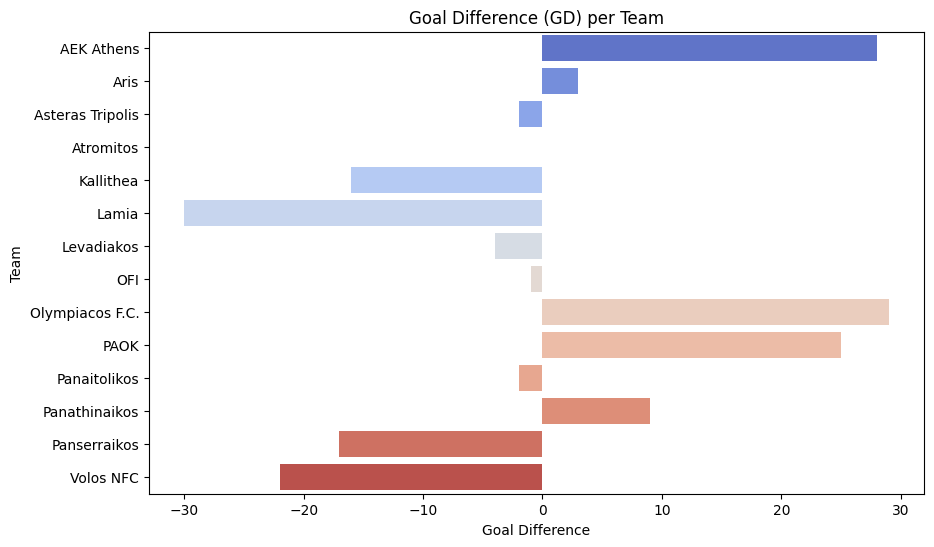


Στατιστικά στοιχεία για το Goal Difference (GD):
count    14.000000
mean      0.000000
std      18.174369
min     -30.000000
25%     -13.000000
50%      -1.500000
75%       7.500000
max      29.000000
Name: GD, dtype: float64


In [ ]:
# Προσθήκη της στήλης Goal Difference (GD)
df['GD'] = df['goals'] - df['goals_conceded']

# Δημιουργία bar plot για το GD
plt.figure(figsize=(10, 6))
sns.barplot(x='GD', y='Team', data=df, palette='coolwarm')
plt.title('Goal Difference (GD) per Team')
plt.xlabel('Goal Difference')
plt.ylabel('Team')
plt.show()

# Στατιστική ανάλυση του GD
print("\nΣτατιστικά στοιχεία για το Goal Difference (GD):")
print(df['GD'].describe())

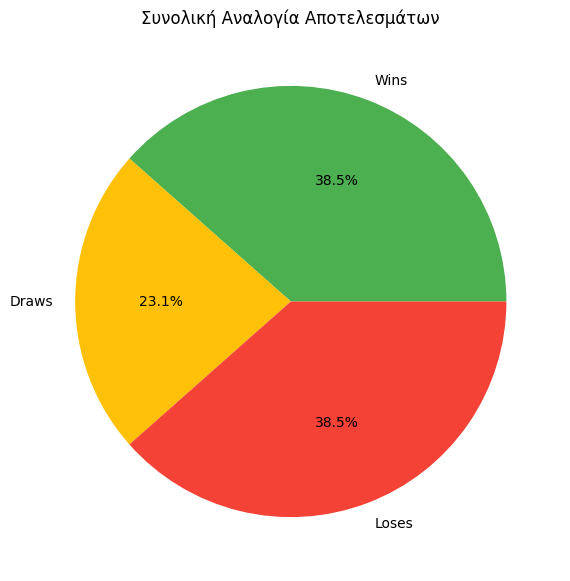

In [ ]:
# Υπολογισμός συνολικών αποτελεσμάτων
totals = df[['Wins', 'Draws', 'Loses']].sum()

# Pie chart για την αναλογία αποτελεσμάτων
plt.figure(figsize=(7, 7))
plt.pie(totals,
        labels=['Wins', 'Draws', 'Loses'],
        autopct='%1.1f%%',
        colors=['#4CAF50', '#FFC107', '#F44336']
       )
plt.title('Συνολική Αναλογία Αποτελεσμάτων')
plt.show()

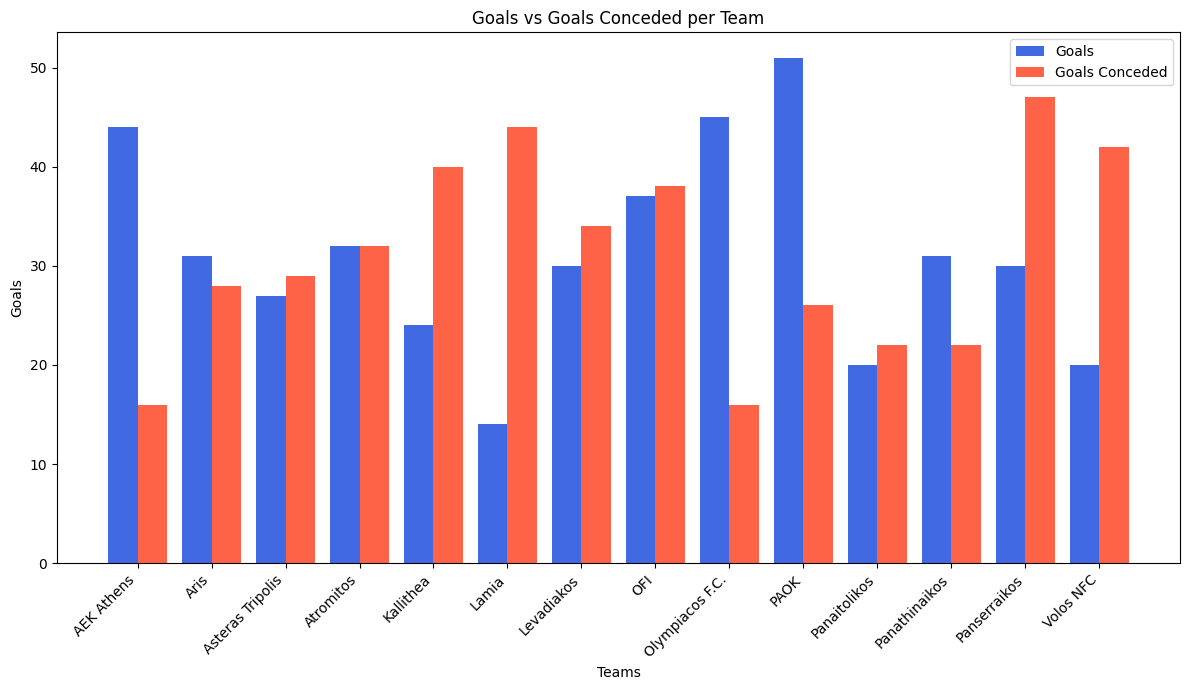

In [ ]:
# Clustered Bar Chart για Goals και Goals Conceded
plt.figure(figsize=(12, 7))

# Ομαδοποίηση δεδομένων
bar_width = 0.4
index = np.arange(len(df['Team']))

# Μπάρες για goals και goals_conceded
plt.bar(index, df['goals'], bar_width, label='Goals', color='royalblue')
plt.bar(index + bar_width, df['goals_conceded'], bar_width, label='Goals Conceded', color='tomato')

# Προσθήκη ετικετών και τίτλων
plt.xlabel('Teams')
plt.ylabel('Goals')
plt.title('Goals vs Goals Conceded per Team')
plt.xticks(index + bar_width / 2, df['Team'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 1. Καλύτερη και Χειρότερη Goal Difference
best_team = df.loc[df['GD'].idxmax(), 'Team']
worst_team = df.loc[df['GD'].idxmin(), 'Team']

print(f"\nΗ ομάδα με την καλύτερη διαφορά γκολ (GD) είναι η {best_team}.")
print(f"Η ομάδα με τη χειρότερη διαφορά γκολ (GD) είναι η {worst_team}.")

# 2. Συσχέτιση μεταξύ Wins και Goals
correlation = df[['goals', 'Wins']].corr().iloc[0, 1]

print(f"\nΗ συσχέτιση μεταξύ των goals που σημείωσε μία ομάδα και των νικών της είναι: {correlation:.2f}")

# 3. Αξιολόγηση Επίθεσης και Άμυνας
print("\nΣύγκριση επίθεσης και άμυνας:")

for index, row in df.iterrows():
    print(f"{row['Team']}: {row['goals']} Goals - {row['goals_conceded']} Conceded")


Η ομάδα με την καλύτερη διαφορά γκολ (GD) είναι η Olympiacos F.C..
Η ομάδα με τη χειρότερη διαφορά γκολ (GD) είναι η Lamia.

Η συσχέτιση μεταξύ των goals που σημείωσε μία ομάδα και των νικών της είναι: 0.82

Σύγκριση επίθεσης και άμυνας:
AEK Athens: 44 Goals - 16 Conceded
Aris: 31 Goals - 28 Conceded
Asteras Tripolis: 27 Goals - 29 Conceded
Atromitos: 32 Goals - 32 Conceded
Kallithea: 24 Goals - 40 Conceded
Lamia: 14 Goals - 44 Conceded
Levadiakos: 30 Goals - 34 Conceded
OFI: 37 Goals - 38 Conceded
Olympiacos F.C.: 45 Goals - 16 Conceded
PAOK: 51 Goals - 26 Conceded
Panaitolikos: 20 Goals - 22 Conceded
Panathinaikos: 31 Goals - 22 Conceded
Panserraikos: 30 Goals - 47 Conceded
Volos NFC: 20 Goals - 42 Conceded
